# Đánh giá điểm tín dụng sử dụng Decision Tree và Random Forest


Mục tiêu:

- Xây dựng mô hình Decision Tree và Random Forest sử dụng thư viện sklearn.
- Ứng dụng, hiểu cách áp dụng hai mô hình để giải bài toán thực tế (vd: đánh gia điểm tín dụng).
- Sử dụng độ đo thích hợp để đánh giá chất lượng mô hình.

Vấn đề:

- Yếu tố then chốt trong việc cho vay tín dụng là khả năng hoàn trả của người vay. Vì vậy đánh giá điểm tín dụng của người dùng là một bài toán được quan tâm trong lĩnh vực tài chính. Nhìn chung, đây là một bài toán phân lọai 2 lớp (good/bad score).
- Hơn nữa, số lượng bad credits thường ít hơn nhiều so với số lượng good credits ==> Dữ liệu nhãn lớp mất cân bằng.

Dữ liệu:

- Thường ở dưới dạng bảng, mỗi hàng là một cá nhân vay, mỗi cột thể hiện một thuộc tính của cá nhân đó.
- Các trường thuộc tính tồn tại ở nhiều dạng: categorical, numeric (discrete / continuous). Thậm chí tên trường có thể được ẩn đi, hay giá trị thật sự được mã hõa để đảm bảo tính bảo mật của khách hàng.
- Hai tập dữ liệu sẽ sử dụng: German credit và Australian credit.

https://archive.ics.uci.edu/ml/datasets/Statlog+(Australian+Credit+Approval)

https://archive.ics.uci.edu/ml/datasets/Statlog+(German+Credit+Data)

Bài toán:

- Đầu vào: N vector D chiều, tương ứng N cá thể với D thuộc tính.
- Đầu ra: nhãn 0-1 (0: bad credit, 1: good credit).

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

random_state = 42

## 1. Tìm hiểu dữ liệu

In [2]:
'''
- Tìm hiểu cấu trúc data tại trang web UCI
- Tải các files, đặt trong thư mục data/
- Làm với phiên bản 'numeric'
'''

from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/Colab Notebooks/ML-exercises/Ex5/Data/german.data-numeric'
credit=np.genfromtxt(data_path)
print(credit)
X,y = credit[:,:-1], credit[:,-1]
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


Mounted at /content/drive
[[ 1.  6.  4. ...  0.  1.  1.]
 [ 2. 48.  2. ...  0.  1.  2.]
 [ 4. 12.  4. ...  1.  0.  1.]
 ...
 [ 4. 12.  2. ...  0.  1.  1.]
 [ 1. 45.  2. ...  0.  1.  2.]
 [ 2. 45.  4. ...  0.  1.  1.]]
(1000, 24) (1000,)
(800, 24) (200, 24)


## 2. Tìm hiểu mô hình Decision Tree, Random Forest của Sklearn

In [3]:
'''
- Decision Tree
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
'''
DT = DecisionTreeClassifier(random_state=random_state)

'''
- Random Forest
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
'''
RF = RandomForestClassifier(random_state=random_state)

In [4]:
print('Demo DT and RF prediction')
DT.fit(X_train, y_train)
y_dt_pred = DT.predict(X_test)
print("-DT acc = {}".format(accuracy_score(y_test, y_dt_pred)))
print("-DT f1 = {}".format(f1_score(y_test, y_dt_pred)))
print("-DT roc auc = {}".format(roc_auc_score(y_test, y_dt_pred)))
print(confusion_matrix(y_test, y_dt_pred))

Demo DT and RF prediction
-DT acc = 0.665
-DT f1 = 0.7632508833922261
-DT roc auc = 0.5948431301839163
[[108  33]
 [ 34  25]]


### Bài 1: Chạy RF baseline

In [5]:
DT.fit(X_train, y_train)
y_dt_pred = DT.predict(X_test)
print("-DT accuracy = {}".format(accuracy_score(y_test, y_dt_pred)))
print("-DT F1 score = {}".format(f1_score(y_test, y_dt_pred)))
print("-DT roc auc = {}".format(roc_auc_score(y_test, y_dt_pred)))
print(confusion_matrix(y_test, y_dt_pred))

-DT accuracy = 0.665
-DT F1 score = 0.7632508833922261
-DT roc auc = 0.5948431301839163
[[108  33]
 [ 34  25]]


## 3. Tìm kiếm siêu tham số

In [6]:
# Utility functions
def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier()
    if algorithm == 'random-forest':
        model = RandomForestClassifier()
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,
                            n_jobs=n_jobs, scoring='f1')
    classifier.fit(X_train, y_train)
    print('Best model', end='')
    print(classifier.best_estimator_)
    return classifier.best_estimator_

def evaluate(model):
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train f1 score :", f1_score(y_train, model.predict(X_train)))
    print("Train roc auc :", roc_auc_score(y_train, model.predict(X_train)))
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test f1 score :", f1_score(y_test, model.predict(X_test)))
    print("Test roc auc :", roc_auc_score(y_test, model.predict(X_test)))
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))

def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5), new_plot=False,
                        idx_color=0):
    # Khởi tạo bức ảnh mới với thư viện plot lib
    if new_plot:
        # plt.figure()
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Score")
        plt.grid()
    # chú thích nếu có
    if ylim is not None:
        plt.ylim(*ylim)

    # thực hiện training model, ghi nhận các giá trị trong quá trình training
    # cv = số fold cross validate, số phần bộ dữ liệu được chia để thực hiện training testing.
    # train_sizes = mảng tỉ lệ, các tỉ lệ được hệ thống chọn làm điểm dừng để thực hiện 1 testing
    #  train_sizes = [0.3, 0.5] => hệ thống lấy 30 % dữ liệu để train và thực hiện test, tương tự 50 % ..
    # scoring = hàm mục tiêu để đánh giá chất lượng mô hình và vẽ lên đồ thị
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="f1")
    # Lấy trung bình cộng các giá trị output của các fold
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # thực hiện vẽ các giá trị số lên đồ thị với màu vừa được random
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='g')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='r',
             label=label_curve['test'])
    plt.plot(train_sizes, train_scores_mean, 'o-', color='g',
             label=label_curve['train'])

    plt.legend(loc="best")
    return plt

### 3.1 Decision Tree

Text(0.5, 1.0, 'DT validation curve for max_depth')

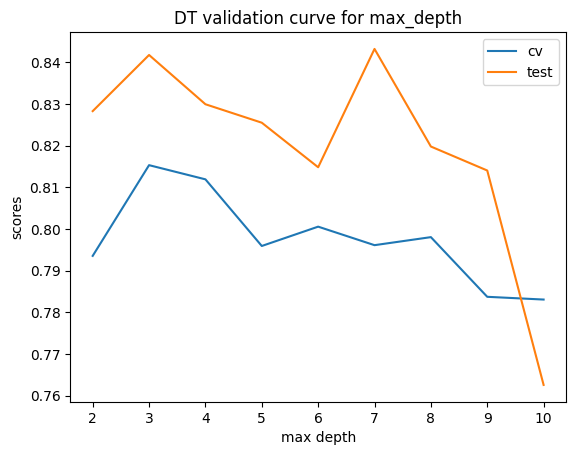

In [7]:
# Trước hết, hãy thử khảo sát DT với tham số max_depth
cv_accuracies_by_depth, test_accuracies_by_depth= [], []
max_depth_values= np.arange(2,11)

for curr_max_depth in max_depth_values:
  tree= DecisionTreeClassifier(random_state=random_state, max_depth=curr_max_depth)

  # cross-validation
  val_scores= cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5, scoring='f1')
  cv_accuracies_by_depth.append(val_scores.mean())

  # test
  tree.fit(X_train, y_train)
  curr_pred= tree.predict(X_test)
  test_accuracies_by_depth.append(f1_score(curr_pred, y_test))

# Plot
plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')

In [8]:
# Thử sử dụng GridSearchCV để khảo sát
dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_tree = grid_search('decision-tree', n_jobs=-1, dict_param=dict_param)


Best modelDecisionTreeClassifier(max_depth=5, min_samples_leaf=20)


### Bài 2: đánh giá best_tree
- Prediction performance
- Learning curve

--- Đánh giá mô hình Decision Tree tốt nhất ---
Train Accuracy : 0.77125
Train f1 score : 0.8473728106755629
Train roc auc : 0.680523905314024
Train Confusion Matrix:
[[508  51]
 [132 109]]
--------------------------------------------------
Test Accuracy : 0.78
Test f1 score : 0.8533333333333334
Test roc auc : 0.6911888448130785
Test Confusion Matrix:
[[128  13]
 [ 31  28]]


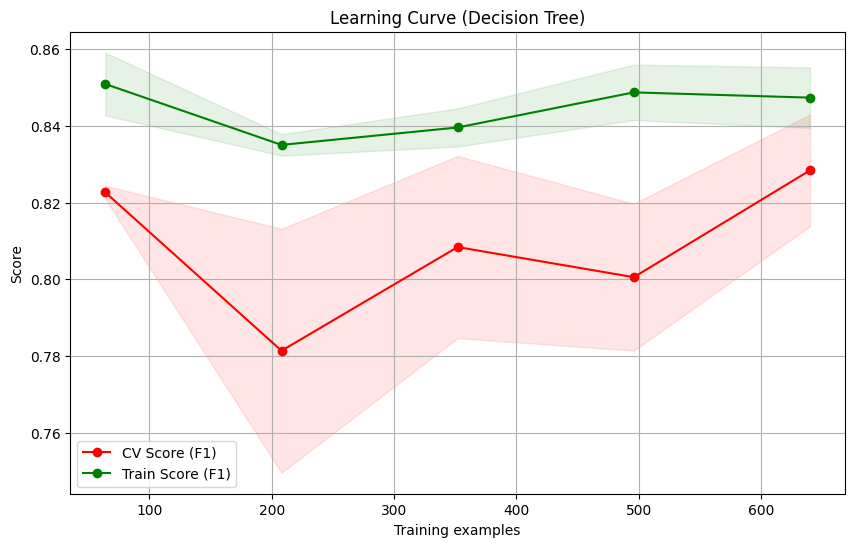

In [9]:
print('--- Đánh giá mô hình Decision Tree tốt nhất ---')
evaluate(best_tree)

# Vẽ Learning Curve
plt.figure(figsize=(10, 6))
title = 'Learning Curve (Decision Tree)'
label_curve = {'train': 'Train Score (F1)', 'test': 'CV Score (F1)'}
plot_learning_curve(best_tree, title, label_curve, X_train, y_train, cv=5, new_plot=True)
plt.show()

Top 10 feature importances
Feature  0 - 0.40445005922715943
Feature  1 - 0.17066428015343657
Feature  2 - 0.14261352910286315
Feature  3 - 0.07120344185816782
Feature  4 - 0.05428847945598893
Feature  5 - 0.05400258515142507
Feature  6 - 0.04007488290946428
Feature  7 - 0.03813781829612112
Feature  8 - 0.015091674891623292
Feature  9 - 0.009473248953750433


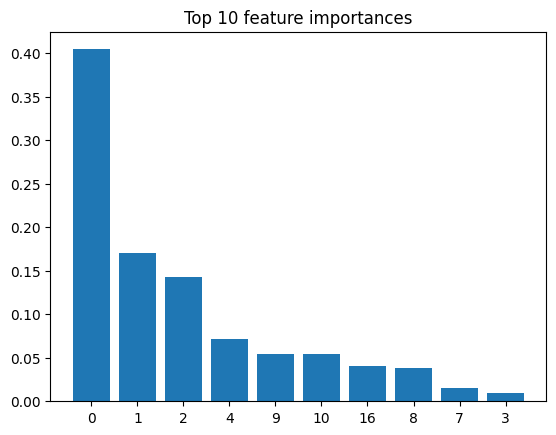

In [10]:
# Nhận xét về độ quan trọng của từng feature
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
print('Top 10 feature importances')
for i in range(10):
    print('Feature ', i, '-', importances[indices[i]])

indices = indices[:10]
plt.figure()
plt.title('Top 10 feature importances')
plt.bar(range(10), importances[indices])
plt.xticks(range(10), indices)
plt.show()

###  3.2 Random Forest

### Bài 3: thực hành tương tự với RF

Text(0.5, 1.0, 'RF validation curve for num_trees')

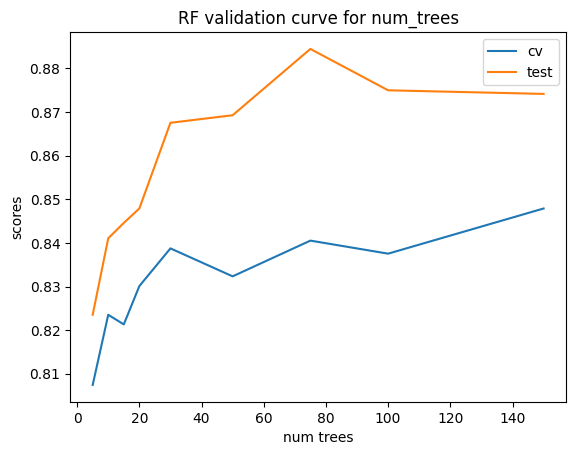

In [11]:
# Bài tập
# Tương tự, thử khảo sát RF với số lượng cây n_estimators
# code
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]
cv_score = []
test_score = []

for curr_num_trees in num_trees:
  rf = RandomForestClassifier(random_state=random_state, n_estimators=curr_num_trees)
  val_scores = cross_val_score(estimator=rf, X=X_train, y=y_train, cv=5, scoring='f1')
  cv_score.append(val_scores.mean())
  rf.fit(X_train, y_train)
  curr_pred = rf.predict(X_test)
  test_score.append(f1_score(curr_pred, y_test))

plt.plot(num_trees, cv_score, label='cv')
plt.plot(num_trees, test_score, label='test')
plt.legend()
plt.xlabel('num trees')
plt.ylabel('scores')
plt.title('RF validation curve for num_trees')

---Tìm Best-forest---
Best modelRandomForestClassifier(max_depth=15, max_features=6, min_samples_leaf=5,
                       n_estimators=75)
--Đánh giá, vẽ Learing Curve---
Train Accuracy : 0.8825
Train f1 score : 0.9211409395973155
Train roc auc : 0.8167815972505733
Train Confusion Matrix:
[[549  10]
 [ 84 157]]
--------------------------------------------------
Test Accuracy : 0.8
Test f1 score : 0.8709677419354839
Test roc auc : 0.6905878110349801
Test Confusion Matrix:
[[135   6]
 [ 34  25]]


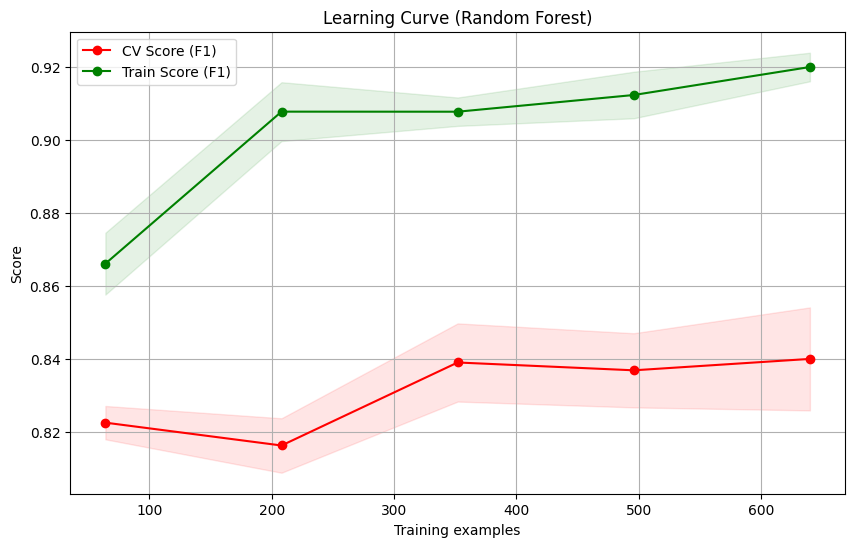

Top 10 feature importances
Feature  0 - 0.17815226759078254
Feature  1 - 0.1313057079951586
Feature  2 - 0.11797987323112419
Feature  3 - 0.10072107274388398
Feature  4 - 0.09312678267534263
Feature  5 - 0.05356884731128738
Feature  6 - 0.046502060989729845
Feature  7 - 0.04207091483603994
Feature  8 - 0.03322701669597386
Feature  9 - 0.030623973633099273


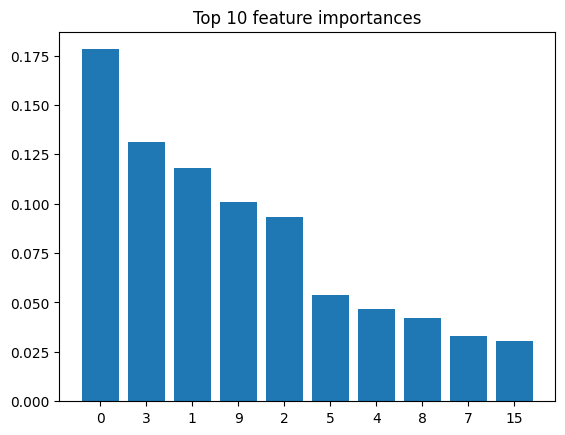

In [13]:
# Sử dụng GridSearch CV
dict_param = {
    'max_depth': [3, 11, 15, 24, 27],
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features':  [4, 6, 10, 16],
    'n_estimators': [75]
}
# Bài tập:
# - tìm best_forest
# - Đánh giá best_forest
# - Vẽ learning curve
# - Tìm hiểu feature importance
# Code

# - Tìm best_forest
# Code
print("---Tìm Best-forest---")
best_forest = grid_search('random-forest', n_jobs=-1, dict_param=dict_param)
# - Đánh giá best_forest và vẽ Learning Curve
print("--Đánh giá, vẽ Learing Curve---")
evaluate(best_forest)
plt.figure(figsize=(10, 6))
title = 'Learning Curve (Random Forest)'
label_curve = {'train': 'Train Score (F1)', 'test': 'CV Score (F1)'}
plot_learning_curve(best_forest, title, label_curve, X_train, y_train, cv=5, new_plot=True)
plt.show()
# - Tìm hiểu feature importance
# Code: Feature importance
importances = best_forest.feature_importances_
indices = np.argsort(importances)[::-1]
print('Top 10 feature importances')
for i in range(10):
    print('Feature ', i, '-', importances[indices[i]])

indices = indices[:10]
plt.figure()
plt.title('Top 10 feature importances')
plt.bar(range(10), importances[indices])
plt.xticks(range(10), indices)
plt.show()

### 3.3 Thử nghiệm bổ sung

#### 3.3.1 Bỏ một số features có độ quan trọng thấp

In [14]:
# Thử bỏ một sô feature có độ quan trọng thấp đi
# Chú ý tham max_features cần thay đổi
sfm = SelectFromModel(best_forest, threshold='mean')
sfm.fit(X_train, y_train)
X_train_dropped = sfm.transform(X_train)
X_test_dropped = sfm.transform(X_test)

title = 'Learning with dropped features'
label_curve = {'train': 'train', 'test':'cv'}
forest_dropped = RandomForestClassifier(max_depth=11, min_samples_leaf=5,
                       n_estimators=75, n_jobs=-1, random_state=random_state)

# plot_learning_curve(forest_dropped, title, label_curve, X_train_dropped, y_train, cv=5)

forest_dropped.fit(X_train_dropped, y_train)
y_dropped_pred = forest_dropped.predict(X_test_dropped)
print('acc', accuracy_score(y_test, y_dropped_pred))
print('f1', f1_score(y_test, y_dropped_pred))
print('roc_auc', roc_auc_score(y_test, y_dropped_pred))

acc 0.79
f1 0.8618421052631579
roc_auc 0.6933525664142326


#### 3.3.2 Một số chiến lược áp dụng cho Random Forest khi gặp phải Class Imbalance
https://machinelearningmastery.com/bagging-and-random-forest-for-imbalanced-classification/

In [15]:
'''
- Standard RF
'''
params = {
    'max_depth': best_forest.get_params()['max_depth'],
    'max_features': best_forest.get_params()['max_features'],
    'min_samples_leaf': best_forest.get_params()['min_samples_leaf'],
    'n_estimators': best_forest.get_params()['n_estimators'],
}
evaluate(best_forest)


Train Accuracy : 0.8825
Train f1 score : 0.9211409395973155
Train roc auc : 0.8167815972505733
Train Confusion Matrix:
[[549  10]
 [ 84 157]]
--------------------------------------------------
Test Accuracy : 0.8
Test f1 score : 0.8709677419354839
Test roc auc : 0.6905878110349801
Test Confusion Matrix:
[[135   6]
 [ 34  25]]


In [16]:
'''
- Random Forest With Class Weighting
'''
rf1 = RandomForestClassifier(max_depth=params['max_depth'], max_features=params['max_features'],
                             min_samples_leaf = params['min_samples_leaf'], n_estimators=params['n_estimators'],
                             class_weight='balanced')
rf1.fit(X_train, y_train)
evaluate(rf1)

Train Accuracy : 0.89875
Train f1 score : 0.92616226071103
Train roc auc : 0.8921421625754348
Train Confusion Matrix:
[[508  51]
 [ 30 211]]
--------------------------------------------------
Test Accuracy : 0.79
Test f1 score : 0.851063829787234
Test roc auc : 0.7475658131987017
Test Confusion Matrix:
[[120  21]
 [ 21  38]]


In [17]:
'''
- Random Forest With Bootstrap Class Weighting
'''
'''
- Random Forest With Class Weighting
'''
rf2 = RandomForestClassifier(max_depth=params['max_depth'], max_features=params['max_features'],
                             min_samples_leaf = params['min_samples_leaf'], n_estimators=params['n_estimators'],
                             class_weight='balanced_subsample')
rf2.fit(X_train, y_train)
evaluate(rf2)

Train Accuracy : 0.89125
Train f1 score : 0.9204025617566332
Train roc auc : 0.8855952018646219
Train Confusion Matrix:
[[503  56]
 [ 31 210]]
--------------------------------------------------
Test Accuracy : 0.78
Test f1 score : 0.841726618705036
Test roc auc : 0.7454020915975478
Test Confusion Matrix:
[[117  24]
 [ 20  39]]


In [18]:
'''
- Random Forest With Random Undersampling
'''
from imblearn.ensemble import BalancedRandomForestClassifier
rf3 = BalancedRandomForestClassifier(max_depth=params['max_depth'], max_features=params['max_features'],
                             min_samples_leaf = params['min_samples_leaf'], n_estimators=params['n_estimators'],
                             )
rf3.fit(X_train, y_train)
evaluate(rf3)

Train Accuracy : 0.85375
Train f1 score : 0.8890995260663507
Train roc auc : 0.8634825080352437
Train Confusion Matrix:
[[469  90]
 [ 27 214]]
--------------------------------------------------
Test Accuracy : 0.76
Test f1 score : 0.8222222222222222
Test roc auc : 0.7410746483952397
Test Confusion Matrix:
[[111  30]
 [ 18  41]]
